# <a href="https://thetahat.ru/courses/ad" target="_top">Введение в анализ данных</a>
## Домашнее задание 6. Основы обработки текстов


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 100 баллов
* Задача 2 &mdash; 50 баллов

Баллы учитываются в <b><font color="green">факультативной части</font></b> курса и не влияют на оценку по основной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [34]:
import re
import time
from collections import Counter, OrderedDict
from string import punctuation
from typing import List

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

from typing import Dict, Tuple

nltk.download("stopwords")
sns.set(style="whitegrid", palette="Set2")

device = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Перед выполнением задания **обязательно посмотрите** <a href="https://thetahat.ru/files/ad/main/6/lec6.pdf" target="_blank" rel="noopener noreferrer">презентацию</a>, <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">ноутбук</a> по RNN и <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part2" target="_top">ноутбук</a> по LLM.

---
### Задача 1. Предсказание заработной платы


В этой задаче вам предлагается решить задачу регрессии &mdash; по текстовому описанию вакансии определить заработную плату. Для решения такой задачи можно применять различные методы, в том числе и те, которые были рассмотрены на лекции.
Мы будем решать эту задачу с помощью рекуррентной нейронной сети.

Датасет `salary_dataset.csv` лежит по <a target="_top" href="https://drive.google.com/file/d/1725ZmFblqrmnyNmqBfUA-7_Yt6RIpf9p/view?usp=sharing">ссылке</a>.

Если вы работаете локально:

> Просто скачайте этот файл и укажите пути к ним ниже.


Если вы используете <a target="_top" href="https://colab.research.google.com/">Colab</a>:
> **Скачивать файл не обязательно**. Просто подключитесь к Google Drive:
>
> ```
> from google.colab import drive
> drive.mount('/content/drive/')
> ```
>
> Перейдите по ссылке файла и добавьте shortcut на него в ваш собственный диск:
> 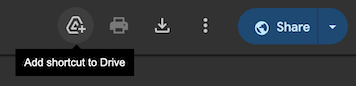

**1.** Скачаем данные для обучения и тестирования:

In [4]:
# подключим Google Drive
from google.colab import drive

drive.mount("/content/drive")

# пути к нужным папкам в Drive
data_path = "/content/drive/MyDrive/salary_data.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dataset = pd.read_csv(data_path)
dataset.head()

,Id,FullDescription,SalaryNormalized
0,12612628,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,12612830,Stress Engineer Glasgow Salary **** to **** We...,30000
2,12612844,Mathematical Modeller / Simulation Analyst / O...,30000
3,12613049,Engineering Systems Analyst / Mathematical Mod...,27500
4,12613647,"Pioneer, Miser Engineering Systems Analyst Do...",25000


Каждая строка содержит полное описание вакансии и соответствующую зарплату. При этом описания могут быть довольно длинными, например:

In [6]:
dataset.iloc[0]["FullDescription"]

'Engineering Systems Analyst Dorking Surrey Salary ****K Our client is located in Dorking, Surrey and are looking for Engineering Systems Analyst our client provides specialist software development Keywords Mathematical Modelling, Risk Analysis, System Modelling, Optimisation, MISER, PIONEEER Engineering Systems Analyst Dorking Surrey Salary ****K'

Для данной задачи нам не будут нужны служебные части речи и знаки пунктуации. Зададим функцию-токенизатор, списки стоп-слов и пунктуации.

In [7]:
def simple_tokenize(text: str) -> List[str]:
    """Базовая предобработка и токенизация по словам"""
    # Приведение к нижнем регистру
    text = text.lower()
    # Убираем пунктуацию, заменяя её на пробел
    text = re.sub(r"[^\w\s]", " ", text)
    # Разбиваем текст на слова
    tokens = text.split()
    return tokens


stop_words = nltk.corpus.stopwords.words("english")  # стоп-слова
punc = list(punctuation)  # пунктуация

Подготовьте словарь, оставив в нем только наиболее часто встречающиеся токены. Не забудьте предварительно убрать из предложений знаки пунктуации и стоп-слова.

*Можно использовать код с <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">семинара</a>.*

In [9]:
# Зададим счетчики
counter = Counter()

# Посчитаем количество вхождений каждого токена
for text in dataset["FullDescription"]:
    # Применяем simple_tokenize, чтобы разбить текст на токены.
    tokenized_text = simple_tokenize(text)

    # Удаляем стоп-слова и пунктуацию
    filtered_tokens = [
        token for token in tokenized_text if token not in stop_words and token not in punc
    ]

    # Все оставшиеся токены добавляем в counter
    counter.update(filtered_tokens)

# Ограничение на словарь
MAX_VOCAB_SIZE = 25000
# Создадим словарь из MAX_VOCAB_SIZE самых частых токенов
ordered_dict = OrderedDict(counter.most_common(MAX_VOCAB_SIZE))

Этот упорядоченный словарь хранит слово и его встречаемость. Можно посмотреть на самые частые слова в датасете:

In [10]:
list(ordered_dict.items())[:10]

[('experience', 428042),
 ('role', 292124),
 ('work', 279785),
 ('team', 268139),
 ('business', 265987),
 ('skills', 235943),
 ('working', 222664),
 ('within', 217339),
 ('sales', 209317),
 ('client', 197545)]

Создайте класс `Vocabulary`, отвечающий за управление словарём токенов. Добавьте к нему специальные токены, которые необходимы для подготовки данных к обучению.

*Можно воспользоваться кодом с <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">семинара</a>.*

In [12]:
class Vocabulary:
    """
    Класс для создания и управления словарем токенов,
        обеспечивающий преобразование
        между токенами и их индексами.
    """

    def __init__(self, word_freq: Dict[str, int]):
        """
        Инициализирует словарь.

        Параметры:
            word_freq: Словарь частот слов, где ключи - слова, значения - частоты.
        """
        self.itos = []  # Индекс -> слово
        self.stoi = {}  # Слово -> индекс
        self.build_vocab(word_freq)

    def build_vocab(self, word_freq: Dict[str, int]):
        """
        Заполняет словарь токенами из word_freq, игнорируя дубликаты.

        Параметры:
            word_freq: Словарь частот слов, где ключи - слова, значения - частоты.
        """
        for word in word_freq:
            self.append_token(word)

    def append_token(self, token: str):
        """
        Добавляет токен в словарь, если его еще нет в stoi.

        Параметры:
            token: Токен для добавления.
        """
        if token not in self.stoi:
            self.itos.append(token)
            self.stoi[token] = len(self.itos) - 1

    def __getitem__(self, token: str) -> int:
        """
        Возвращает индекс токена.
        Если токен отсутствует в словаре, возвращает индекс <unk>.

        Параметры:
            token: Токен, для которого нужно вернуть индекс.

        Возвращает:
            Индекс токена.
        """
        return self.stoi.get(token, self.stoi["<unk>"])

    def __len__(self) -> int:
        return len(self.itos)

    def set_default_index(self, index: int):
        """
        Установить индекс по умолчанию для отсутствующих токенов.

        Параметры:
            index: Индекс для установки в качестве дефолтного.
        """
        self.default_index = index

    def tokens_to_indices(self, tokens: List[str]) -> List[int]:
        """
        Преобразует список токенов в список индексов.

        Параметры:
            tokens: Список токенов для преобразования.

        Возвращает:
           Список индексов.
        """
        return [self[token] for token in tokens]

    def lookup_tokens(self, indices: List[int]) -> List[str]:
        """
        Преобразует список индексов обратно в список токенов.

        Параметры:
            indices: Список индексов для преобразования.

        Возвращает:
            Список токенов.
        """
        return [self.itos[idx] if idx < len(self.itos) else "<unk>" for idx in indices]


# Создание словаря
vocab = Vocabulary(ordered_dict)

Теперь добавим специальные токены.

In [13]:
unk_token = "<unk>"
pad_token = "<pad>"

Напишем функцию для добавления специальных токенов.

In [14]:
def add_special_tokens(vocab: Vocabulary) -> Tuple[Vocabulary, int, int]:
    """
    Функция для добавления специальных токенов в словарь.
    Специальные токены:
        - <unk>: Токен для обозначения неизвестных слов.
        - <pad>: Токен для паддинга последовательностей.

    Параметры:
        vocab: Словарь Vocabulary для добавления специальных токенов.

    Возвращает:
        vocab: Обновленный словарь Vocabulary.
        UNK_IDX: Индекс токена <unk>.
        PAD_IDX: Индекс токена <pad>.
    """
    for special_token in [unk_token, pad_token]:
        vocab.append_token(special_token)

    vocab.set_default_index(vocab[unk_token])
    UNK_IDX = vocab[unk_token]
    PAD_IDX = vocab[pad_token]
    return vocab, UNK_IDX, PAD_IDX


vocab, UNK_IDX_EN, PAD_IDX_EN = add_special_tokens(vocab)
UNK_IDX_EN, PAD_IDX_EN

# num_tokens = len(vocab)

(25000, 25001)

Подготовьте класс датасета.

In [15]:
class SalaryPredictionDataset(Dataset):
    """
    Класс датасета для предсказания зарплаты в формате torch.Dataset
    Элементами этого датасета должны быть пары (текст, таргет)
    """

    def __init__(self, texts: List[List[int]], target: List[float]):
        """
        Параметры.
        1) texts (list) — корпус токенизированных текстов, на котором будет
                          происходить обучение
        2) labels (list) — истинные метки текстов
        """
        self.texts = texts
        self.target = target

    def __len__(self) -> int:
      return len(self.target)

    def __getitem__(self, idx: int) -> Tuple[List[int], float]:
        """
        Возвращает один пример данных по индексу.

        Параметры:
            idx: Индекс примера

        Возвращает:
            Токенизированный текст
            Метку зарплаты
        """
        return self.texts[idx], self.target[idx]

Допишите функцию для дополнения текста до максимальной длины в батче. Снова воспользуйтесь кодом с <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">семинара</a>.

*Обратите внимание, что теперь вместо целочисленных меток мы используем вещественные таргеты. Если не поменять код с семинара, то вы можете решать неправильную задачу.*

In [16]:
def pad_collate(
    batch: List[Tuple[List[int], int]],
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Формирует тензоры из токенизированных текстов и меток, а также
    дополняет последовательности токенов до максимальной длины в батче с UNK_IDX

    Параметры:
        batch: Список примеров, где каждый пример - кортеж из:
            - Списка индексов токенов
            - Целевая переменная

    Возвращает:
        Кортеж содержащий:
            - Тензор текстов с паддингом, shape = (batch_size, max_len)
            - Тензор целевых переменных, shape = (batch_size,)
    """
    texts, target = zip(*batch)

    texts_tensors = [torch.LongTensor(t) for t in texts]
    target_tensors = torch.FloatTensor(target)

    # дополним до макс. длины в батче
    texts_tensors = pad_sequence(
        texts_tensors, padding_value=PAD_IDX_EN, batch_first=True
    )

    return texts_tensors, target_tensors

Токенизируем текст, а таргет переведем во `float`.

In [17]:
tokens = [vocab.tokens_to_indices(simple_tokenize(d)) for d in dataset["FullDescription"]]
target = np.array([float(d) for d in dataset["SalaryNormalized"]])

Каждому из текстов в датасете сопоставляется последовательность токенов, причем везде разного размера:

In [18]:
for i in range(3):
    print(f"Количество токенов в {i}-м тексте - {len(tokens[i])}:\n  ", end="")
    for token in tokens[i][:10]:
        print(token, end=", ")
    print("...\nТаргет:", target[i], "\n")

Количество токенов в 0-м тексте - 44:
  84, 68, 288, 7523, 963, 39, 82, 25000, 9, 25000, ...
Таргет: 25000.0 

Количество токенов в 1-м тексте - 240:
  2700, 74, 1909, 39, 25000, 25000, 25000, 107, 16, 25000, ...
Таргет: 30000.0 

Количество токенов в 2-м тексте - 238:
  3587, 6008, 3179, 288, 435, 288, 2669, 1370, 25000, 25000, ...
Таргет: 30000.0 



При решении задач регрессии с помощью нейросетей удобнее всего бывает перевести предсказываемые значения в небольшой диапазон, например, от 0 до 1. Это нужно, чтобы повысить численную стабильность обучения &mdash; не нагружать модель большими значениями таргетов. В нашей задаче это важно, ведь зарплата может иметь большой разброс и принимать большие значения.

Чтобы сделать это, воспользуемся преобразованием `MinMaxScaler` из библиотеки `sklearn`, которое мы рассматривали в <a href="https://thetahat.ru/courses/ad/main/1/vvad_hw1" target="_top">задаче 2 задания 1</a>.


Таким образом, мы получим значения, удобные для использования при обучении.

**Вопрос**. По каким данным предсказываемого значения нужно подбирать параметры преобразование `MinMaxScaler`?

По краям зарплатного диапазона

Разбейте данные на трейн и валидацию и сделайте нормализацию таргета с помощью `MinMaxScaler`.

In [19]:
train_tokens, valid_tokens, train_target, valid_target = train_test_split(
    tokens, target
)

scaler = MinMaxScaler()
train_target_std = scaler.fit_transform(np.array(train_target).reshape(-1, 1))
valid_target_std = scaler.transform(np.array(valid_target).reshape(-1, 1))

train_data = SalaryPredictionDataset(train_tokens, train_target_std)
valid_data = SalaryPredictionDataset(valid_tokens, valid_target_std)
len(train_data), len(valid_data)

(183576, 61192)

In [20]:
print(train_data[0])

([54, 2993, 8, 178, 136, 11, 260, 25000, 109, 8, 11, 198, 25000, 3672, 25000, 4422, 39, 891, 536, 2450, 25000, 25000, 279, 25000, 25000, 2993, 8, 178, 25000, 38, 25000, 25000, 313, 384, 30, 25000, 25000, 3672, 25000, 4422, 25000, 9, 1605, 25000, 2002, 266, 25000, 313, 6, 25000, 98, 25000, 85, 25000, 663, 25000, 6470, 25000, 313, 1523, 25000, 2033, 25000, 4, 981, 25000, 0, 25000, 2062, 25000, 25000, 310, 25000, 45, 25000, 313, 2172, 1068, 25000, 25000, 121, 112, 25000, 4130, 118, 15, 41, 25000, 18, 25000, 47, 12, 504, 25000, 512, 40, 25000, 700, 25000, 486, 25000, 499, 25000, 25000, 99, 25000, 313, 112, 25000, 25000, 25000, 16142, 2243, 25000, 25000, 25000, 25000, 362, 25000, 25000, 6848, 25000, 218, 68, 25000, 25000, 9728, 663, 25000, 12540, 25000, 2, 10787, 25000, 25000, 198, 25000, 2420, 2992, 25000, 25000, 700, 25000, 25000, 313, 25000, 720, 25000, 25000, 3237, 25000, 2, 25000, 25000, 441, 25000, 25000, 441, 25000, 0, 25000, 271, 8148, 268, 41, 59, 25000, 25000, 396, 25000, 25000, 2

Посмотрите на несколько отмасштабированных значений зарплат, визуализируйте гистограммы значений до нормализации и после нормализации.

In [21]:
print("3 реобразованных таргета:")
for t in train_data[:3][1]:
    print(round(t.item(), 4), end=" ")

3 реобразованных таргета:
0.0641 0.1103 0.1667 

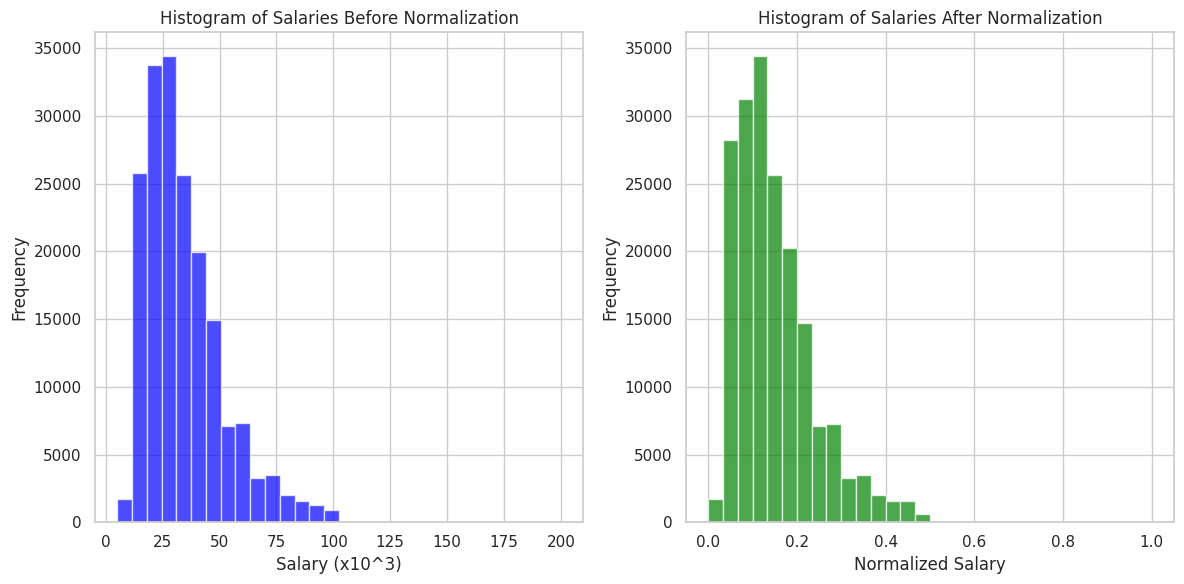

In [22]:
# Визуализация гистограмм
plt.figure(figsize=(12, 6))

# Гистограмма до нормализации
plt.subplot(1, 2, 1)
plt.hist(np.array(train_target) / 1000, bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Salaries Before Normalization')
plt.xlabel('Salary (x10^3)')
plt.ylabel('Frequency')

# Гистограмма после нормализации
plt.subplot(1, 2, 2)
plt.hist(train_target_std, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Salaries After Normalization')
plt.xlabel('Normalized Salary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Сформируйте даталоадеры для обучения и валидации.

In [23]:
BATCH_SIZE = 64  # размер батча

# сформируем даталоадеры
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_collate)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate)

**2.** Наконец, можем подготовить модель. Будем использовать рекуррентную архитектуру, подобную той, что была на <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">семинаре</a>.

Отличия будут состоять в том, что теперь мы предсказываем не метку класса, а вещественный таргет. Помимо этого, будем чуть более грамотно работать с последовательностью скрытых состояний. Для каждой последовательности в батче для предсказания будем использовать последнее скрытое состояние, которое соответсвутет **не `<pad>`-токену**. Напомним, что в батче мы добиваем все последовательности до одинаковый длины через паддинг. Теперь, после прогона RNN, для каждой последовательности найдем крайний токен исходной последовательности, игнорируя скрытые состояния, которые соответствуют `<pad>`-токенам. Из этого крайнего токена и сделаем предсказания с помощью еще одного линейного слоя.

In [48]:
class SimpleRNNRegressor(nn.Module):
    """Модель для задачи регрессии на основе RNN."""

    def __init__(
        self,
        num_tokens,
        emb_size=128,
        rnn_num_units=64,
        output_dim=1
    ):
        """
        Параметры:
            num_tokens: Размер словаря (количество уникальных токенов)
            emb_size: Размерность эмбеддингов
            rnn_num_units: Размер скрытого состояния RNN
            output_dim: Размерность выходного слоя (для регрессии обычно 1)
        """
        super(SimpleRNNRegressor, self).__init__()

        self.emb = nn.Embedding(num_tokens, emb_size, padding_idx=PAD_IDX_EN)
        self.rnn = nn.RNN(emb_size, rnn_num_units, batch_first=True)
        self.classifier = nn.Linear(rnn_num_units, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход модели.

        Параметры:
            x: Входной тензор индексов токенов (batch_size, sequence_length)

        Возвращает:
            predictions - предсказания модели.
        """
        # x.shape = (batch_size, max_pad_len)

        # Получим эмбеддинги для входов
        # (batch_size, max_pad_len, emb_size)
        emb = self.emb(x)

        # Прогоним через RNN-сеть
        # (batch_size, max_pad_len, rnn_num_units)
        rnn_output, _ = self.rnn(emb)

        # Создадим маску паддинга
        # (batch_size, max_pad_len)
        padding_mask = (x != PAD_IDX_EN)

        # Определим длины последовательностей
        lengths = padding_mask.sum(dim=1)

        # Для каждой последовательности найдем последнее скрытое состояние,
        # соответствующее не <pad>-токену
        batch_size = x.size(0)
        last_hidden_states = []

        for i in range(batch_size):
            # Получаем индекс последнего токена в последовательности
            last_idx = lengths[i] - 1
            # Получаем соответствующее скрытое состояние
            last_hidden_states.append(rnn_output[i, last_idx, :])

        # Собираем все последние скрытые состояния в один тензор
        last_hidden_states = torch.stack(last_hidden_states)

        # Прогоним через полносвязный слой и получим предсказания
        predictions = self.classifier(last_hidden_states)
        return predictions

Так как теперь решаем задачу регрессии, вместо точности модели будем измерять среднеквадратичную ошибку:

In [25]:
def mse(preds: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Возвращает среднеквадратичную ошибку модели.

    Параметры.
    1) preds — предсказания модели,
    2) y — истинные значения таргета.
    """

    return F.mse_loss(preds, y, reduction="mean")

Напишите функцию для цикла обучения и все необходимые вспомогательные функции для обучения, валидации и визуализации результатов. Воспользуйтесь кодом с <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">семинара</a>.

In [26]:
def train(model, iterator, optimizer, criterion, train_loss_history):
    """
    Функция 1 эпохи обучения модели и подсчёта её точности.

    Параметры:
        model: Обучаемая нейросетевая модель
        iterator: Итератор по батчам обучающего датасета
        optimizer: Оптимизатор для обновления весов
        criterion: Функция потерь (например, BCELoss)
        train_loss_history: Список для сохранения истории лосса

    Возвращает:
        Средние значения loss и accuracy за эпоху
    """

    epoch_loss = 0
    epoch_mse = 0
    model.train()

    # Проход по всему датасету
    for batch_id, batch in enumerate(iterator):
        # Обучение на 1 батче, подсчет метрики
        # чтобы градиент не накапливался, его нужно обнулить
        optimizer.zero_grad()
        # получим предсказания модели
        texts, labels = batch
        texts, labels = texts.to(device), labels.to(device)
        predictions = model(texts).squeeze(1)
        loss = criterion(predictions, labels.float())
        acc = mse(predictions, labels)

        # сделаем back-propagation для подсчёта градиентов
        loss.backward()
        # выполним шаг оптимизатора
        optimizer.step()
        # обновим метрики
        epoch_loss += loss.item()
        epoch_mse += acc.item()
        train_loss_history.append(loss.item())

    return epoch_loss / len(iterator), epoch_mse / len(iterator)


def evaluate(model, iterator, criterion, val_loss_history=None):
    """Оценка модели на валидационном/тестовом наборе данных.

    Args:
        model: Оцениваемая модель
        iterator: Итератор по батчам валидационного датасета
        criterion: Функция потерь
        val_loss_history: Опциональный список для истории потерь

    Возвращает:
        Средние значения loss и accuracy
    """

    epoch_loss = 0
    epoch_mse = 0

    model.eval()

    with torch.no_grad(): # отключим подсчёт градиентов на валидации
        # Проход по всему датасету
        for batch_id, batch in enumerate(iterator):
            # Обучение на 1 батче, подсчет метрики
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device)
            # получим предсказания
            predictions = model(texts).squeeze(1)
            # посчитаем метрики
            loss = criterion(predictions, labels.float())
            acc = mse(predictions, labels)
            # обновим метрики
            epoch_loss += loss.item()
            epoch_mse += acc.item()
            if val_loss_history is not None:
                val_loss_history.append(loss.item())

    return epoch_loss / len(iterator), epoch_mse / len(iterator)


def epoch_time(start_time, end_time):
    """
    Функция для подсчёта времени работы одной эпохи.

    Параметры:
        start_time: Время начала в секундах
        end_time: Время окончания в секундах

    Возвращает:
        Минуты и секунды
    """

    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [27]:
def training_loop(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    n_epochs: int = 10,
):
    """
    Функция для обучения нейронной сети.

    Параметры:
        model: Обучаемая нейросетевая модель
        train_loader: Итератор по батчам обучающего датасета
        valid_loader: Итератор по батчам валидационного датасета
        optimizer: Оптимизатор для обновления весов
        criterion: Функция потерь
        n_epochs: Количество эпох
    """

    best_valid_loss = float("inf")
    loss_history = []
    val_loss_history = []
    acc_history = []
    val_acc_history = []

    for epoch in range(n_epochs):
        start_time = time.time()
        # Обучим одну эпоху на обучающем датасете
        train_loss, train_acc = train(model, train_loader, optimizer, criterion, loss_history)
        acc_history.append(train_acc)

        # Оценим точность модели на тестовом датасете
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, val_loss_history)
        val_acc_history.append(valid_acc)

        # Посчитаем время работы одной эпохи
        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Отобразим графики loss'ов
        clear_output(True)
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.plot(loss_history)
        plt.title("Train Loss")
        plt.xlabel("Номер батча")
        plt.subplot(1, 3, 2)
        plt.plot(val_loss_history, color="tab:orange")
        plt.title("Valid Loss")
        plt.xlabel("Номер батча")
        # Если значение функции потерь улучшилось, сохраним параметры модели
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), "model_checkpoint.pt")

        # Отрисуем значение точности от эпохи
        plt.subplot(1, 3, 3)
        plt.plot(acc_history, label="Train")
        plt.plot(val_acc_history, label="Valid")
        plt.legend()
        plt.title("Accuracy")
        plt.xlabel("Номер эпохи")
        plt.show()

        print(f"Номер эпохи: {epoch+1:02} | Время обучения эпохи: {epoch_mins}m {epoch_secs}s")

In [ ]:
# def training_loop(
#     model_instance: nn.Module,
#     criterion,
#     optimizer: torch.optim.Optimizer,
#     n_epochs: int = 10,
# ):
#     """
#     Функция для обучения нейронной сети.

#     Параметры.
#     1) model_instance — обучаемая модель,
#     2) Лосс для обучения модели
#     3) Оптимизатор для обучения
#     4) n_epochs — количество эпох.
#     """
#     ...

In [28]:
num_tokens = len(vocab)

In [39]:
# Задайте параметры сети
model = SimpleRNNRegressor(
    num_tokens=num_tokens,
    emb_size=128,
    rnn_num_units=256,
).to(device)

# У нас задача регрессии, будем использовать MSELoss
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
history = []

# Посмотрите на получившуюся модель
model

SimpleRNNRegressor(
  (emb): Embedding(25002, 128, padding_idx=25001)
  (rnn): RNN(128, 256, batch_first=True)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

**3.** Обучите несколько моделей с различными гиперпараметрами (например, шаг обучения, размер словаря, архитектура) и сравните их качество на тестовой выборке.

*Не пугайтесь, если у вас не будет получаться хорошее качество на валидации: решаемая задача довольно сложная, а RNN &mdash; достаточно простая архитектура. Но постарайтесь, чтобы модель хотя бы не вырождалась в константу. Для этого следите за переобучением!*

*На 3 курсе вы сможете познакомиться с моделями, которые решают такую задачу гораздо лучше.*

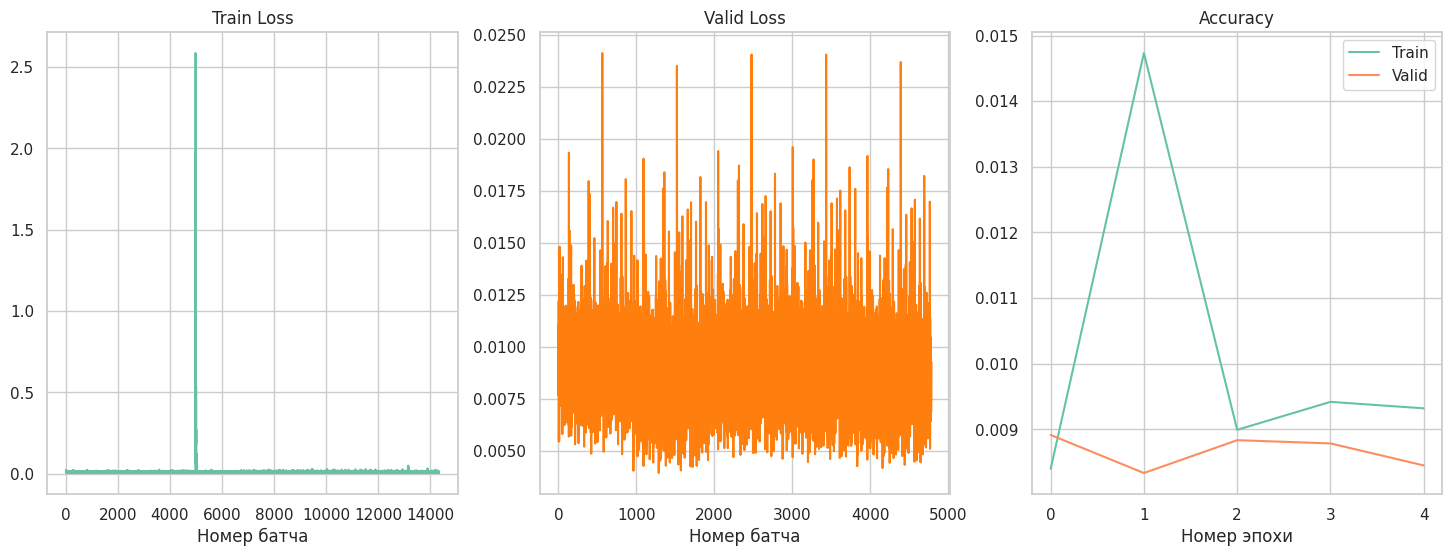

Номер эпохи: 05 | Время обучения эпохи: 3m 27s


In [41]:
training_loop(model, train_loader, valid_loader, optimizer, criterion, n_epochs=5)

Для второй модели уменьшим шаг обучения

In [49]:
# Задайте параметры сети
model_second = SimpleRNNRegressor(
    num_tokens=num_tokens,
    emb_size=128,
    rnn_num_units=256,
).to(device)
# Используем оптимизатор Adam, о нем вы сможете узнать на курсах DS-потока!
optimizer = torch.optim.Adam(model_second.parameters(), lr=0.05)
history_second = []

# Посмотрите на получившуюся модель
model_second

SimpleRNNRegressor(
  (emb): Embedding(25002, 128, padding_idx=25001)
  (rnn): RNN(128, 256, batch_first=True)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

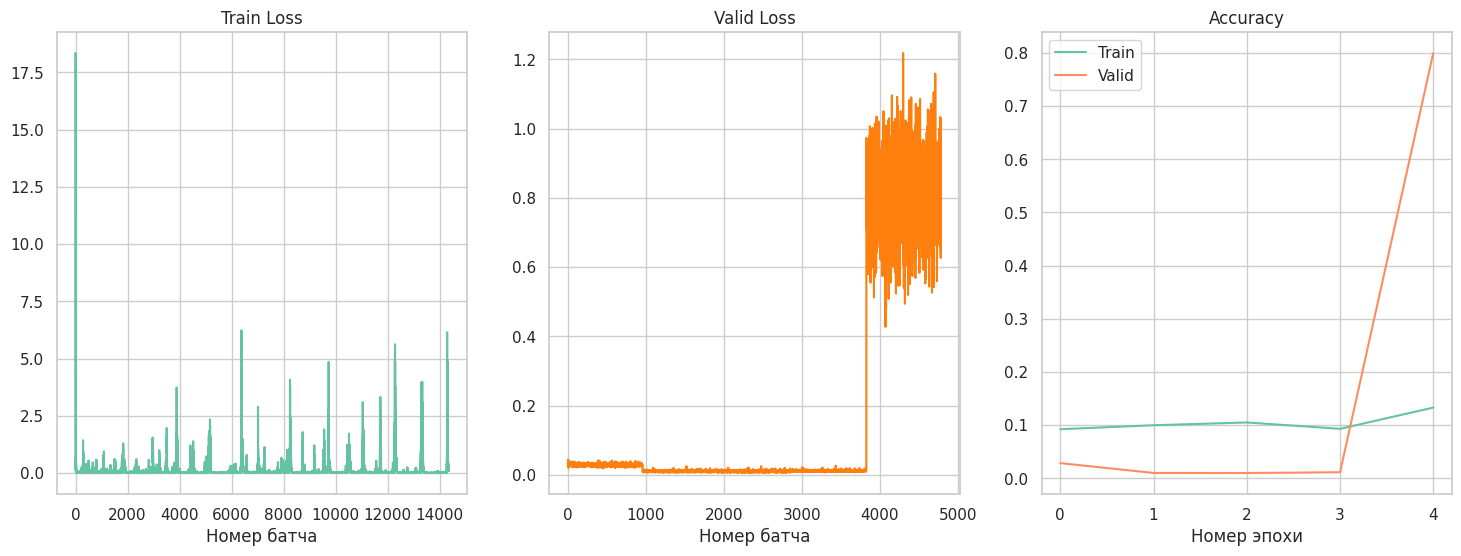

Номер эпохи: 05 | Время обучения эпохи: 3m 27s


In [50]:
training_loop(model_second, train_loader, valid_loader, optimizer, criterion, n_epochs=5)

Теперь уменьшим словарь и заново создадим его. Lr = 0.05, такой менее точный, но наглядный

In [52]:
# Ограничение на словарь
MAX_VOCAB_SIZE = 25000
# Создадим словарь из MAX_VOCAB_SIZE самых частых токенов
ordered_dict = OrderedDict(counter.most_common(MAX_VOCAB_SIZE))

# зададим словарь
vocab = Vocabulary(ordered_dict)

vocab, UNK_IDX_EN, PAD_IDX_EN = add_special_tokens(vocab)
num_tokens = len(vocab)

In [53]:
tokens = [vocab.tokens_to_indices(simple_tokenize(d)) for d in dataset["FullDescription"]]
target = np.array([float(d) for d in dataset["SalaryNormalized"]])

In [54]:
train_tokens, valid_tokens, train_target, valid_target = train_test_split(
    tokens, target
)

In [55]:
scaler = MinMaxScaler()
train_target_std = scaler.fit_transform(np.array(train_target).reshape(-1, 1))
valid_target_std = scaler.transform(np.array(valid_target).reshape(-1, 1))

train_data = SalaryPredictionDataset(train_tokens, train_target_std)
valid_data = SalaryPredictionDataset(valid_tokens, valid_target_std)
len(train_data), len(valid_data)

(183576, 61192)

На батче того же размера

In [56]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_collate
)

valid_loader = DataLoader(
    valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate
)

In [57]:
# Задайте параметры сети
model_third = SimpleRNNRegressor(
    num_tokens=num_tokens,
    emb_size=128,
    rnn_num_units=256,
).to(device)
# Используем оптимизатор Adam, о нем вы сможете узнать на курсах DS-потока!
optimizer = torch.optim.Adam(model_third.parameters(), lr=0.05)
history_third = []

# Посмотрите на получившуюся модель
model_second

SimpleRNNRegressor(
  (emb): Embedding(25002, 128, padding_idx=25001)
  (rnn): RNN(128, 256, batch_first=True)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

In [60]:
# Посмотрите на получившуюся модель
model_third

SimpleRNNRegressor(
  (emb): Embedding(25002, 128, padding_idx=25001)
  (rnn): RNN(128, 256, batch_first=True)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

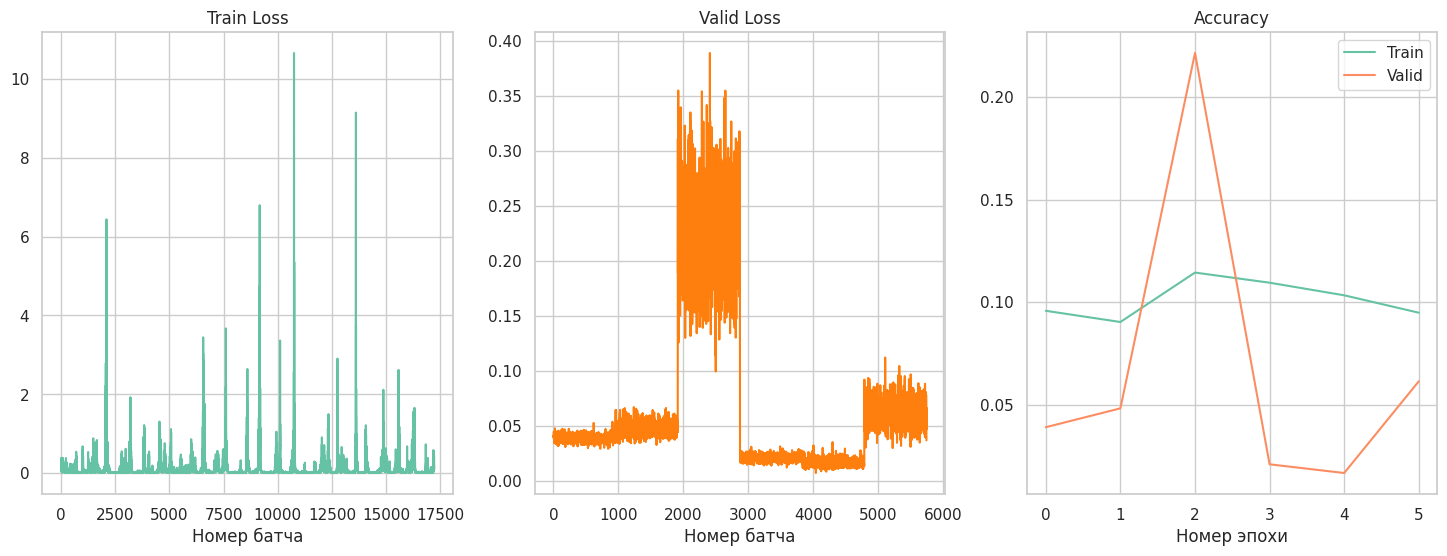

Номер эпохи: 06 | Время обучения эпохи: 3m 27s


In [59]:
training_loop(model_third, train_loader, valid_loader, optimizer, criterion, n_epochs=6)

Выведите несколько примеров работы на валидационной выборке: **текст вакансии, предсказание вашей модели и истинное значение зарплаты.** Чтобы вернуть все значения к изначальным масштабам, используйте `scaler.inverse_transform(...)`. Также посчитайте итоговый MSE на всей валидационной выборке.

In [ ]:
data_batch, targets_batch = next(iter(valid_loader))  # загрузим один батч данных

# применим модель, получим предсказания
with torch.no_grad():
    preds = scaler.inverse_transform(model(data_batch.to(device)).cpu())
    targets_batch = scaler.inverse_transform(targets_batch)

In [ ]:
# Выведем предсказания для 5 случайных примера из тестового батча
indices = torch.randint(low=0, high=len(data_batch), size=(5,))
for idx in indices:
    print("=" * 20)
    print("Text:")
    text = " ".join(
        [
            token
            for token in vocab.lookup_tokens(data_batch[idx].tolist())
            if token not in ["<unk>", "<pad>"]
        ]
    )
    print(text)
    print(f"Predicted salary: {preds[idx].item()}")
    print(f"True salary: {targets_batch[idx].item()}")
    print()

Text:
client leading global built asset consultancy part group access circa professionals worldwide operating 70 countries 300 offices generating excess billion revenue currently looking building services engineer provide electrical engineering design input meet engineering services duties london borough ealing service agreement responsibilities perform detailed design mechanical engineering services schemes initial client brief final handover client carry option appraisals feasibility condition survey specialist technical reports mechanical engineering services installations preparation tender documents including design drawings technical specifications major new build projects minor works maintenance refurbishment works mechanical engineering services schemes act contract administrator ca mechanical engineering services projects include preparation pricing schedules pretender estimates tender reports certification stage payments practical completion making good defects chair minute p

In [62]:
def calculate_mse(model, dataloader, device):
    model.eval()  # Переводим модель в режим оценки
    total_loss = 0
    total_samples = 0

    with torch.no_grad():  # Отключаем вычисление градиентов
        for batch in dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            # Получаем предсказания модели
            predictions = model(inputs)

            # Вычисляем MSE для текущего батча
            loss = mse(predictions, targets)
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

    # Вычисляем среднее MSE по всем батчам
    mse_value = total_loss / total_samples
    return mse_value

# Пример использования
mse_value = calculate_mse(model_third, valid_loader, device)
print(f' итоговый MSE на валидационной выборке: {mse_value}')

 итоговый MSE на валидационной выборке: 0.06227637357315311


**Вывод:**

Была построена нейронная сеть с рекуррентной архитектурой для задачи угадывания зарплаты по описанию.
Сеть была изменена и обучена на различных гиперпараметрах. При меньшем lr, сеть обучалась медленне, но была относительно стабильнее. При меньшем объёме словаря график MSE стал более резким.
В следующи раз следует заранее посчитать время на обучение.

---
### Задача 2. Использование LLM.

В рамках семинара мы реализовали модель на основе RNN для задачи анализа тональности текста, обучив её на датасете отзывов IMDB и добившись неплохих результатов. Затем мы посмотрели на пример использования LLM, таких как `Qwen-2.5-3B`, для решения той же задачи. В этой задаче вам предложено провести расширенное сравнительное исследование, оценив эффективность нескольких LLM в различных форматах: zero-/few-shot.

---
**Форматы zero-/few-shot**

Современные большие языковые модели (LLM), обученные следовать инструкциям, позволяют решать задачи классификации, если правильно оформить запрос к ним. Подготовку надежной инструкции для решения задачи иногда еще называют промптингом. Подробнее можно почитать <a href="https://docs.mistral.ai/guides/prompting_capabilities/" target="_top">здесь</a> или <a href="https://huggingface.co/docs/transformers//tasks/prompting" target="_top">здесь</a>, или самостоятельно обсудить с LLM!


Рассмотрим два довольно популярных подхода.
* *Zero-Shot* \
  Модель выполняет задачу, опираясь только на инструкцию, без дополнительных примеров. Допустим вы можете сформулировать запрос к модели так:
  ```
  Определи, POSITIVE или NEGATIVE тон у этого текста: {текст}.
  ```
  <br>
* *Few-Shot* \
  Модель получает $k$ **примеров вместе с ответом** перед основным запросом. Это позволяет познакомить модель, например, с форматом ответа и показать какие-то паттерны через демонстрацию. \
  Рассмотрим возможный `2-shot` формат. Он предполагает демонстрацию на **двух примерах вместе с референсным ответом**. Третьим запросом будет идти целевой:

  ```
  Пример 1: "Фильм ужасен..." → NEGATIVE
  Пример 2: "Это шедевр!" → POSITIVE
  Задача: Определи тональность для "{текст}".
  ```

Обратим внимание, что Few-Shot-подход можно реализовать разными способами в зависимости от API или чат-интерфейса модели.

1. Использовать системный промпт и указать инструкцию вместе с примерами прямо там.

```
system_prompt = """
Ты классифицируешь тональность текста. Вот примеры:  
- "Фильм ужасен..."\nОтвет: NEGATIVE  
- "Это шедевр!"\nОтвет: POSITIVE  
Отвечай только метками POSITIVE/NEGATIVE.  
"""
```

В таком случае в `user`-реплике будет содержаться только текст целевого отзыва. При этом можно поступить иначе и использовать, например, стандартный системный промпт, рекомендованный разработчиками модели. Тогда инструкцию и few-shot примеры можно поместить сразу в `user`-реплику.


2. Используя чат-шаблон (chat-template). Тогда k-shot вариант можно реализовать следующим образом:

```
{"role": "system", "content": "Ты классифицируешь тональность текста."},  # Общая инструкция в сис. промпте, но можно и в user-реплику!
{"role": "user", "content": "Отзыв: 'Сюжет скучный...'\nОтвет:"},         # Пример 1
{"role": "assistant", "content": "NEGATIVE"},                             # Важно: ответ модели заполнен нами самостоятельно! Его можно взять из train-сета
...
{"role": "user", "content": "Отзыв: 'Лучший фильм года!'\nОтвет:"},       # Пример k
{"role": "assistant", "content": "POSITIVE"},                             # Ответ для примера k
{"role": "user", "content": "Отзыв: '{review}'\nОтвет:"}                  # Тут расположен целевой пример для прогона
```
В данном случае $k$ примеров, которые можно взять из обучающей выборки, вместе с ответами и примером для инференса принудительно помещены в историю диалога. Модель, генерируя след. реплику, выдаст нам ответ на задачу, а примеры в контексте позволят лучше следовать формату ответа и потенциально повысят итоговое качество.

Выбор стратегии, вообще говоря, зависит от пользователя и ограничений модели. Например, некоторые модели могут не поддерживать системный промпт.

---

Итак, вам требуется применить **две** open-source LLM для задачи sentiment analysis с семинара и сравнить их производительность в режимах zero- и few-shot на **валидационной выборке**. Для few-shot используйте $k=5$ примеров, которые возьмите случайным образом из обучающей выборки. Это факультативная часть курса, поэтому выбор конкретного формата, из описанных выше, остается на вашей стороне :)


**Подумайте**, должны ли few-shot примеры быть сбалансированы, то есть содержать приблизительно одинаковое кол-во позитивных и негативных примеров?

В качестве LLM используйте `Qwen/Qwen2.5-3B` и `unsloth/Llama-3.2-1B-Instruct` с HuggingFace. Попробуйте **поэкспериментировать с различными вариантами промпта**. Можете взять за основу пример с семинара и воспользоваться ИИ-инструментами для его усовершенствования. Сравните результат с моделью на базе RNN, полученной на семинаре.

Представьте результат в виде аккуратной таблицы, в которой укажите модель вместе с используемым форматом (zero-/few-shot), а также итоговую точность (accuracy). Сделайте выводы.

In [ ]:
# установка нужных библиотек
!pip install datasets
!pip install vllm

In [ ]:
import torch
import transformers

from datasets import Dataset, load_dataset
from enum import Enum


from transformers import AutoModelForCausalLM, AutoTokenizer, AutoProcessor

from pprint import pprint
from pydantic import BaseModel

import re
import time
from collections import Counter, OrderedDict
from random import sample
from string import punctuation
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import names as names_data
from datasets import load_dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

sns.set(style="whitegrid", palette="Set2")
nltk.download("names")
nltk.download("stopwords")

device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(transformers.__version__)
print(torch.__version__)

[nltk_data] Downloading package names to /root/nltk_data...


4.51.2
2.6.0+cu124


[nltk_data]   Unzipping corpora/names.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Выборка:

In [ ]:
data = load_dataset("scikit-learn/imdb", split="train").train_test_split(test_size=0.2, seed=42)

train_iter, test_iter = data["train"], data["test"]

train_dataset = list(train_iter)
test_dataset = list(test_iter)

README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

IMDB%20Dataset.csv:   0%|          | 0.00/66.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
inputs = train_dataset[:2000]

In [ ]:
# Возьмем китайскую модель qwen-2.5
# подробнее: https://github.com/QwenLM/Qwen2.5
model_name = "Qwen/Qwen2.5-3B"

# Инициализируем модель
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto", device_map="auto")

# Инициализируем токенизатор
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
# Функция для применения модели к тексту
def apply_model_to_text(text, model, tokenizer, device, prompt):
    inputs = tokenizer(prompt + text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=50)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# Zero-shot и few-shot эксперименты
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

for model_name in model_names:
    model = models[model_name]
    tokenizer = tokenizers[model_name]
    model.to(device)

    # Zero-shot
    zero_shot_prompt = "Determine the sentiment of the following text:\n"
    zero_shot_accuracy = evaluate_model(model, tokenizer, device, valid_dataset, zero_shot_prompt)
    results.append((model_name, "zero-shot", zero_shot_accuracy))

    # Few-shot
    few_shot_examples = random.sample(train_dataset, 5)
    few_shot_prompt = "Determine the sentiment of the following text based on the examples provided:\n"
    few_shot_accuracy = evaluate_model(model, tokenizer, device, valid_dataset, few_shot_prompt, few_shot_examples)
    results.append((model_name, "few-shot", few_shot_accuracy))

# Вывод результатов
print("Model | Format | Accuracy")
print("----------------------------")
for model_name, format, accuracy in results:
    print(f"{model_name} | {format} | {accuracy:.4f}")

NameError: name 'model_names' is not defined

**Вывод:**

Ничего не понятно. Результатов получить не удалось